# 3rd-class women

The pocket `error_analysis.ipynb` flags as the biggest opportunity: 144 passengers, 72 survived,
72 died, and the gender baseline is guessing.

Two questions here, in order. What separates them? And how much of it is the shipped model
*already* getting — because the gender rule's errors are not the same as the current model's.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

from preprocessing import build_preprocessing_pipeline
from train import MODELS

# raw stays untouched: the OOF cell below must feed the model exactly the columns the real
# pipeline expects, not the helper columns added for plotting
raw = pd.read_csv("data/train.csv")
df = raw.copy()
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["FamLarge"] = (df["FamilySize"] >= 5).astype(int)
df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("size")
df["FarePerPerson"] = df["Fare"] / df["TicketGroupSize"]

pocket = df[(df["Sex"] == "female") & (df["Pclass"] == 3)].copy()
pocket["FamBucket"] = pd.cut(pocket["FamilySize"], [0, 1, 2, 4, 20], labels=["alone", "2", "3-4", "5+"])
pocket["FareBand"] = pd.qcut(pocket["Fare"], 3, labels=["low", "mid", "high"])
pocket["AgeBand"] = pd.cut(pocket["Age"], [0, 10, 18, 30, 100])
print(f"n={len(pocket)}, survived={pocket['Survived'].sum()}, died={(1 - pocket['Survived']).sum()}")

n=144, survived=72, died=72


## Candidate signals

Every per-passenger attribute the pipeline can currently see, inside the pocket.

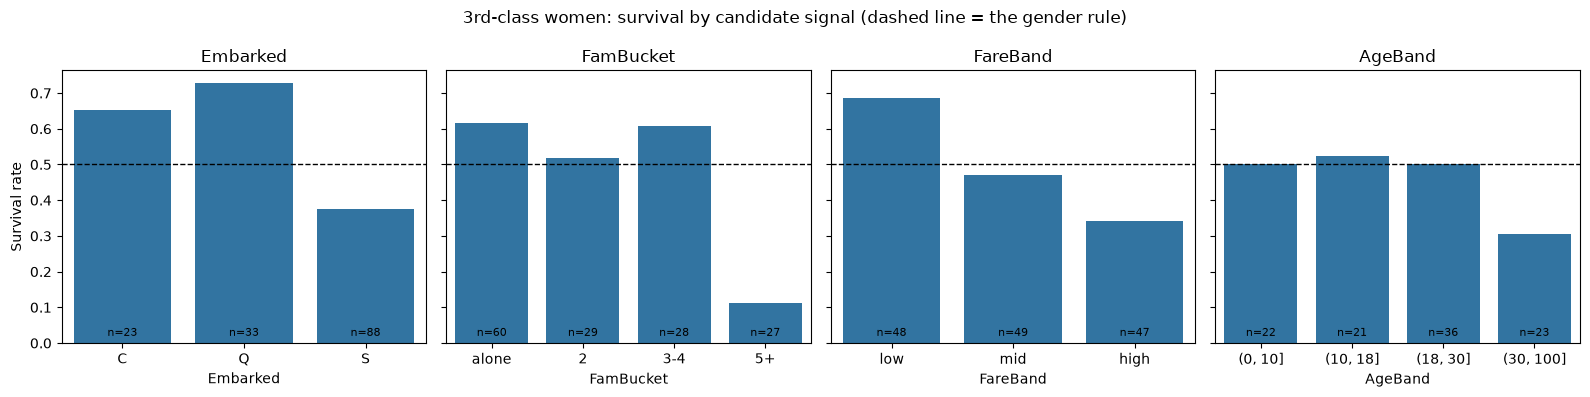

In [2]:
# a 0.5 line marks the gender rule -- a bar has to leave that line to be worth anything
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, col, order in zip(
    axes,
    ["Embarked", "FamBucket", "FareBand", "AgeBand"],
    [["C", "Q", "S"], ["alone", "2", "3-4", "5+"], ["low", "mid", "high"], None],
):
    sns.barplot(data=pocket, x=col, y="Survived", order=order, ax=ax, errorbar=None)
    counts = pocket[col].value_counts()
    for i, level in enumerate(order if order else sorted(pocket[col].dropna().unique())):
        ax.text(i, 0.02, f"n={counts.get(level, 0)}", ha="center", fontsize=8)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("Survival rate")
plt.suptitle("3rd-class women: survival by candidate signal (dashed line = the gender rule)")
plt.tight_layout()
plt.show()

## Is Southampton a real signal, or a proxy?

`Embarked = S` looks like the biggest single lever: 88 of the 144, surviving at 37.5%. But large
families also boarded disproportionately at Southampton, so the two need separating.

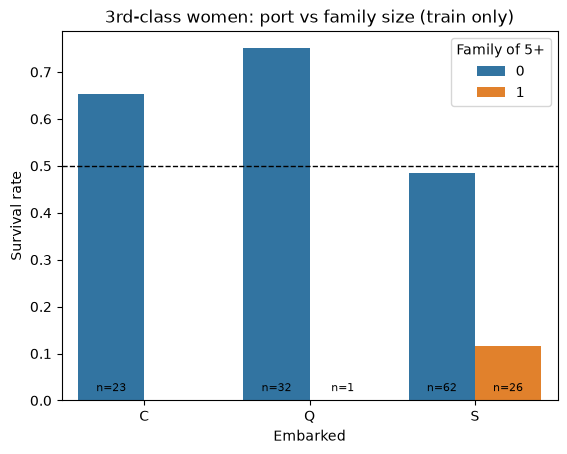

In [3]:
# survival by port, split by whether the passenger is in a family of 5+
ax = sns.barplot(data=pocket, x="Embarked", y="Survived", hue="FamLarge", order=["C", "Q", "S"], errorbar=None)
sizes = pocket.groupby(["FamLarge", "Embarked"]).size()
bars = [bar for container in ax.containers for bar in container]
for bar, (key, n) in zip(bars, sizes.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, 0.02, f"n={n}", ha="center", fontsize=8)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.legend(title="Family of 5+")
plt.ylabel("Survival rate")
plt.title("3rd-class women: port vs family size (train only)")
plt.show()

In [4]:
# candidate rules, scored in rows gained against "all women survive"
rules = {
    "Embarked S -> died": pocket["Embarked"].eq("S"),
    "Family 5+ -> died": pocket["FamLarge"].eq(1),
    "S or family 5+ -> died": pocket["Embarked"].eq("S") | pocket["FamLarge"].eq(1),
    "S but NOT family 5+ -> died": pocket["Embarked"].eq("S") & pocket["FamLarge"].eq(0),
}
scored = []
for name, mask in rules.items():
    predicted = np.where(mask, 0, 1)
    correct = int((predicted == pocket["Survived"]).sum())
    hits = int((pocket.loc[mask, "Survived"] == 0).sum())
    scored.append({
        "rule": name, "flips": int(mask.sum()), "flips_correct": hits,
        "hit_rate": round(hits / max(mask.sum(), 1), 3),
        "accuracy": round(correct / len(pocket), 3), "net_rows": correct - 72,
    })
pd.DataFrame(scored).set_index("rule")

,flips,flips_correct,hit_rate,accuracy,net_rows
rule,,,,,
Embarked S -> died,88,55,0.625,0.653,22
Family 5+ -> died,27,24,0.889,0.646,21
S or family 5+ -> died,89,56,0.629,0.660,23
S but NOT family 5+ -> died,62,32,0.516,0.514,2


## What is the shipped model already getting?

The map in `error_analysis.ipynb` is drawn against the *gender baseline*. For deciding what to
build next, the relevant errors are the ones the current model still makes.

In [5]:
# out-of-fold predictions from the real gradient_boosting config
config = yaml.safe_load(open("configs/gradient_boosting.yaml"))
model = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(config["features"])),
    ("model", MODELS[config["model"]](**config["params"])),
])
X, y = raw.drop(columns=["Survived"]), raw["Survived"]
oof = pd.Series(index=X.index, dtype=int)
for train_idx, test_idx in StratifiedKFold(5, shuffle=True, random_state=42).split(X, y):
    oof.iloc[test_idx] = model.fit(X.iloc[train_idx], y.iloc[train_idx]).predict(X.iloc[test_idx])

in_pocket = (X["Sex"] == "female") & (X["Pclass"] == 3)
fam_large = X["SibSp"] + X["Parch"] + 1 >= 5
from_s = X["Embarked"].eq("S")

rows = []
for label, mask in [
    ("all 3rd-class women", in_pocket),
    ("family 5+", in_pocket & fam_large),
    ("small family, from S", in_pocket & ~fam_large & from_s),
    ("small family, from C/Q", in_pocket & ~fam_large & ~from_s),
]:
    n = int(mask.sum())
    rows.append({
        "subgroup": label, "n": n,
        "gender_rule": round(float((y[mask] == 1).mean()), 3),
        "shipped_model": round(float((oof[mask] == y[mask]).mean()), 3),
        "model_errors": int((oof[mask] != y[mask]).sum()),
    })
subgroups = pd.DataFrame(rows).set_index("subgroup")
subgroups["net_vs_rule"] = (subgroups["shipped_model"] - subgroups["gender_rule"]) * subgroups["n"]
subgroups.round(3)

,n,gender_rule,shipped_model,model_errors,net_vs_rule
subgroup,,,,,
all 3rd-class women,144,0.500,0.701,43,28.944
family 5+,27,0.111,0.852,4,20.007
"small family, from S",62,0.484,0.581,26,6.014
"small family, from C/Q",55,0.709,0.764,13,3.025


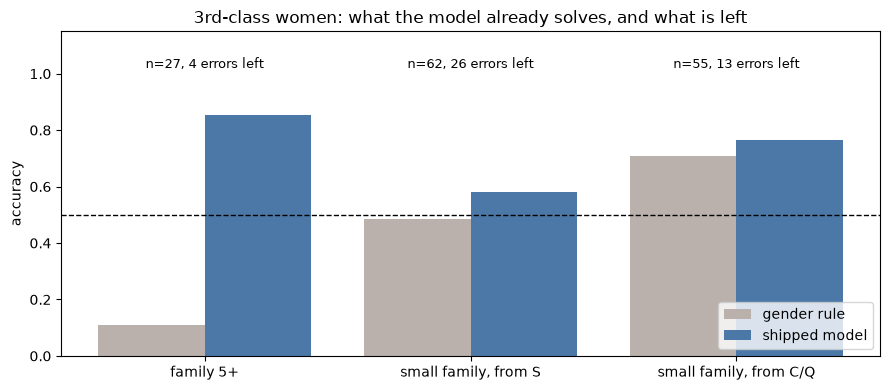

In [6]:
# the same thing as a picture: how much of the pocket is already solved
plot = subgroups.drop(index="all 3rd-class women")
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(plot))
ax.bar(x - 0.2, plot["gender_rule"], 0.4, label="gender rule", color="#bab0ac")
ax.bar(x + 0.2, plot["shipped_model"], 0.4, label="shipped model", color="#4c78a8")
for i, row in enumerate(plot.itertuples()):
    ax.text(i, 1.02, f"n={row.n}, {row.model_errors} errors left", ha="center", fontsize=9)
ax.set_xticks(x, plot.index)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("accuracy")
ax.set_title("3rd-class women: what the model already solves, and what is left")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Conclusions

**There is one signal in this pocket, and you already have it.** Family of 5+ separates it cleanly:
27 women, 11% survival, and flipping just those 27 rows gains 21 of the 72 available. `family_group`
is already in the pipeline, and out-of-fold the shipped model gets that subgroup 85% right.

**Southampton is a proxy, not a signal.** `Embarked = S` looks worth +22 rows on its own, but large
families boarded there disproportionately. Control for family size and "S but not a large family"
is worth **+2 rows** — a coin flip with extra steps. This is the trap in reading the first chart:
the biggest bar is not the biggest signal.

**The pocket is 2/3 solved already.** Against the gender rule's 50%, the shipped model is at 70%
out-of-fold — +29 of the 72 theoretically available rows. What is left is one subgroup:

> **3rd-class women, small family, embarked Southampton — 62 passengers, model at 58%, 26 errors.**

**And that is where per-passenger attributes run out.** 62 rows is not enough to mine further:
any split produces subgroups of 20-30, where the standard error on a survival rate is ~10pp. Six
candidate features tested on 62 rows will produce a convincing-looking winner whether or not one
exists. The honest options are to accept the pocket as solved as far as this data allows, or to
bring information from *outside* the passenger's own row — which is what the surname/ticket-group
feature does, and why it is the standard unlock for this dataset.

---

# Second pass: the residual

Everything above says the same thing -- family of 5+ is the signal, and the other candidates are
its shadow. `Embarked = S` dissolved when family size was controlled; so does "a male on the same
ticket" (59.1% vs 58.3% among small families, versus 32% vs 60% before controlling).

So every view below drops the 27 solved women and looks only at the **117 remaining**, where the
survival rate is 59% and the model is at roughly a coin flip. If a pattern is real it has to show
up here, not in the full pocket.

In [7]:
# the residual: 3rd-class women NOT in a family of 5+
residual = pocket[pocket["FamLarge"] == 0].copy()
residual["Title"] = residual["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
residual["Surname"] = residual["Name"].str.split(",").str[0].str.strip()
males_per_ticket = df.assign(m=(df["Sex"] == "male").astype(int)).groupby("Ticket")["m"].transform("sum")
residual["WithMale"] = (males_per_ticket[residual.index] > 0).astype(int)
residual["AgeMissing"] = residual["Age"].isna().astype(int)
residual["IsMother"] = ((residual["Parch"] > 0) & ((residual["Age"] >= 18) | (residual["Title"] == "Mrs"))).astype(int)
residual["Alone"] = (residual["FamilySize"] == 1).astype(int)
residual["TicketNumber"] = pd.to_numeric(
    residual["Ticket"].str.extract(r"(\d+)$", expand=False), errors="coerce"
)
print(f"residual n={len(residual)}, survived={residual['Survived'].sum()} "
      f"({residual['Survived'].mean():.1%})")

residual n=117, survived=69 (59.0%)


## 1. Every candidate at once, with its uncertainty

A binary split is only interesting if its confidence interval clears zero. At n=117 most will not --
that is the point of drawing the bars.

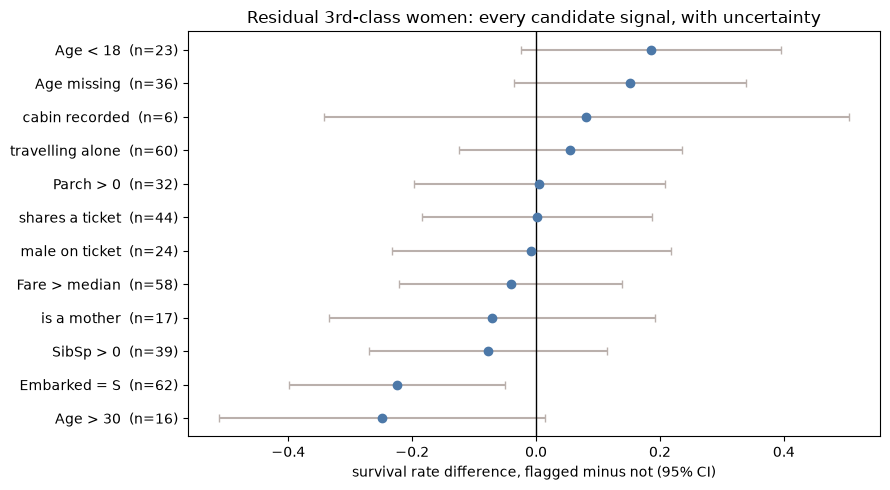

,n_flagged,rate_in,rate_out,gap,se
signal,,,,,
Age > 30,16,0.375,0.624,-0.249,0.134
Embarked = S,62,0.484,0.709,-0.225,0.089
SibSp > 0,39,0.538,0.615,-0.077,0.098
is a mother,17,0.529,0.600,-0.071,0.134
Fare > median,58,0.569,0.610,-0.041,0.092
male on ticket,24,0.583,0.591,-0.008,0.115
shares a ticket,44,0.591,0.589,0.002,0.095
Parch > 0,32,0.594,0.588,0.006,0.103
travelling alone,60,0.617,0.561,0.055,0.092


In [8]:
candidates = {
    "Embarked = S": residual["Embarked"].eq("S"),
    "male on ticket": residual["WithMale"].eq(1),
    "travelling alone": residual["Alone"].eq(1),
    "is a mother": residual["IsMother"].eq(1),
    "Age missing": residual["AgeMissing"].eq(1),
    "Age < 18": residual["Age"].lt(18),
    "Age > 30": residual["Age"].gt(30),
    "Parch > 0": residual["Parch"].gt(0),
    "SibSp > 0": residual["SibSp"].gt(0),
    "Fare > median": residual["Fare"].gt(residual["Fare"].median()),
    "shares a ticket": residual["TicketGroupSize"].gt(1),
    "cabin recorded": residual["Cabin"].notna(),
}

rows = []
for name, mask in candidates.items():
    inside, outside = residual.loc[mask, "Survived"], residual.loc[~mask, "Survived"]
    if len(inside) < 5 or len(outside) < 5:
        continue
    gap = inside.mean() - outside.mean()
    se = np.sqrt(inside.var(ddof=1) / len(inside) + outside.var(ddof=1) / len(outside))
    rows.append({"signal": name, "n_flagged": len(inside), "rate_in": inside.mean(),
                 "rate_out": outside.mean(), "gap": gap, "se": se})
effects = pd.DataFrame(rows).set_index("signal").sort_values("gap")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(effects["gap"], np.arange(len(effects)), xerr=1.96 * effects["se"],
            fmt="o", color="#4c78a8", ecolor="#bab0ac", capsize=3)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(np.arange(len(effects)), [f"{i}  (n={n})" for i, n in zip(effects.index, effects["n_flagged"])])
ax.set_xlabel("survival rate difference, flagged minus not (95% CI)")
ax.set_title("Residual 3rd-class women: every candidate signal, with uncertainty")
plt.tight_layout()
plt.show()
effects.round(3)

## 2. Two continuous variables at once

Marginal bars cannot show a region; a scatter can.

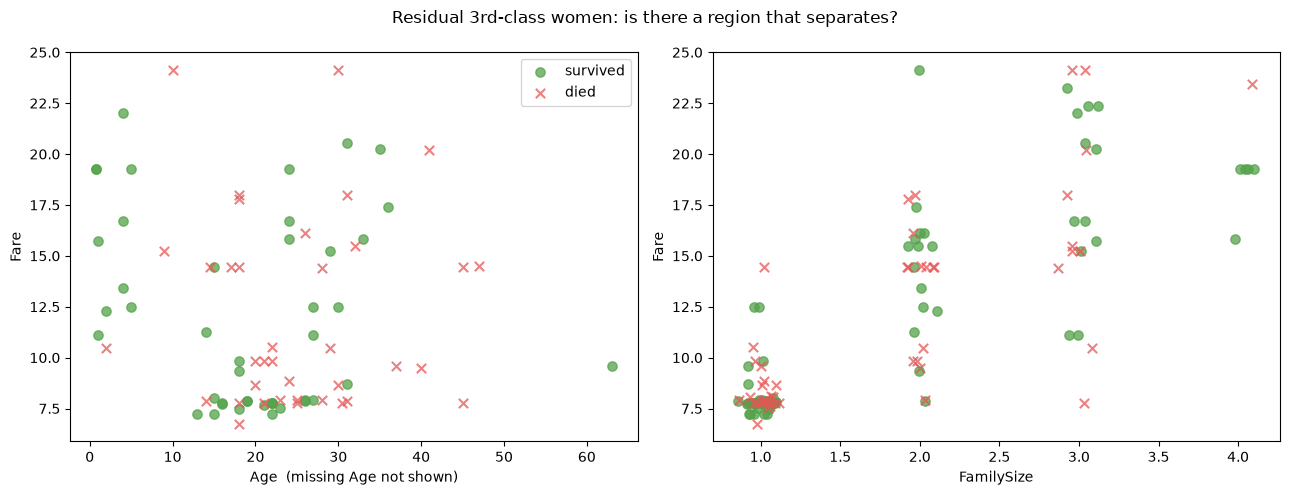

In [9]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))
survived = residual["Survived"] == 1
for ax, xcol, ycol in [(left, "Age", "Fare"), (right, "FamilySize", "Fare")]:
    jitter = np.random.default_rng(0).normal(0, 0.06, len(residual)) if xcol == "FamilySize" else 0
    ax.scatter(residual.loc[survived, xcol] + (jitter[survived.to_numpy()] if xcol == "FamilySize" else 0),
               residual.loc[survived, ycol], color="#54a24b", label="survived", alpha=0.75, s=45)
    ax.scatter(residual.loc[~survived, xcol] + (jitter[~survived.to_numpy()] if xcol == "FamilySize" else 0),
               residual.loc[~survived, ycol], color="#e45756", marker="x", label="died", alpha=0.75, s=45)
    ax.set_xlabel(f"{xcol}  (missing Age not shown)" if xcol == "Age" else xcol)
    ax.set_ylabel(ycol)
plt.suptitle("Residual 3rd-class women: is there a region that separates?")
left.legend()
plt.tight_layout()
plt.show()

## 3. Family composition

SibSp and Parch describe *who* a passenger travelled with, not just how many.

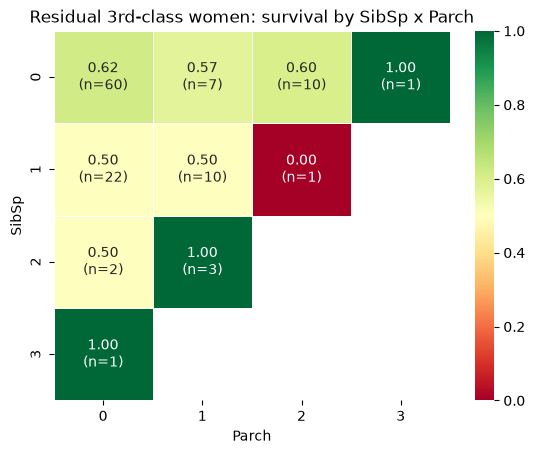

In [10]:
rate = residual.pivot_table(index="SibSp", columns="Parch", values="Survived", aggfunc="mean")
counts = residual.pivot_table(index="SibSp", columns="Parch", values="Survived", aggfunc="size")
labels = rate.map(lambda v: "" if pd.isna(v) else f"{v:.2f}") + counts.map(
    lambda n: "" if pd.isna(n) else f"\n(n={int(n)})")
sns.heatmap(rate, annot=labels, fmt="", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, center=0.5)
plt.title("Residual 3rd-class women: survival by SibSp x Parch")
plt.show()

## 4. Let the algorithm propose a split

Rather than guessing candidates, fit a shallow tree on the residual alone and see what it reaches
for -- then cross-validate it, because a tree will always find *something* in 117 rows.

depth 1: cross-validated accuracy on the residual 0.547 +/- 0.089   (predicting 'survived' for all = 0.590)
depth 2: cross-validated accuracy on the residual 0.553 +/- 0.091   (predicting 'survived' for all = 0.590)
depth 3: cross-validated accuracy on the residual 0.572 +/- 0.083   (predicting 'survived' for all = 0.590)


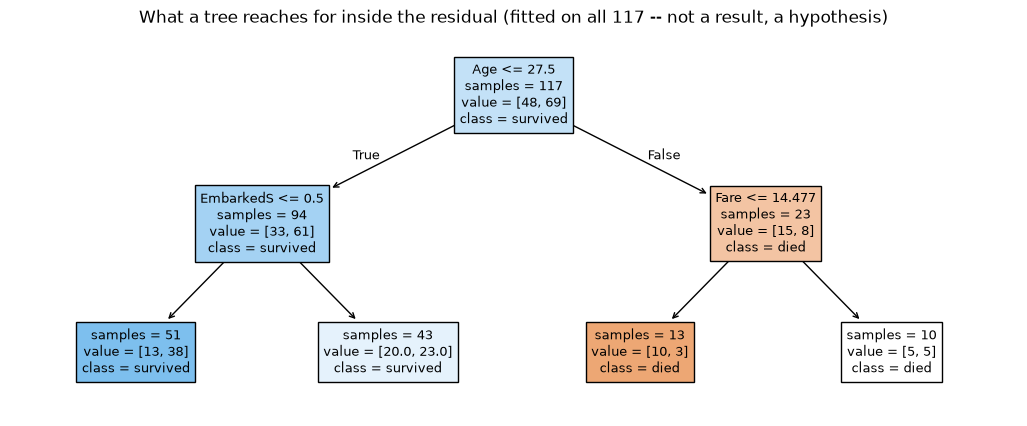

In [11]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

features = residual[["Age", "Fare", "SibSp", "Parch", "FamilySize", "TicketGroupSize",
                     "AgeMissing", "WithMale", "IsMother"]].copy()
features["Age"] = features["Age"].fillna(residual["Age"].median())
features["EmbarkedS"] = residual["Embarked"].eq("S").astype(int)
target = residual["Survived"]

for depth in (1, 2, 3):
    scores = cross_val_score(
        DecisionTreeClassifier(max_depth=depth, min_samples_leaf=10, random_state=0),
        features, target, scoring="accuracy",
        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0),
    )
    print(f"depth {depth}: cross-validated accuracy on the residual "
          f"{scores.mean():.3f} +/- {scores.std():.3f}   (predicting 'survived' for all = 0.590)")

fitted = DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, random_state=0).fit(features, target)
plt.figure(figsize=(13, 5))
plot_tree(fitted, feature_names=features.columns.tolist(), class_names=["died", "survived"],
          filled=True, impurity=False, fontsize=9)
plt.title("What a tree reaches for inside the residual (fitted on all 117 -- not a result, a hypothesis)")
plt.show()

## What these say

Read the first chart before the others: if a signal's interval crosses zero, the pattern you think
you see in the scatter or the heatmap is the same noise drawn differently.

The tree in section 4 is the honest test. It will always produce a split -- the question is whether
its cross-validated accuracy beats 0.590, which is what you get by predicting "survived" for every
one of the 117. If it does not, there is no per-passenger pattern left in this pocket, and the
remaining 43 errors need information from outside the passenger's own row.